In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../datasets/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv")

In [3]:
df.head()

df.tail()

df.sample(5)

df.shape

df.columns

df.info()

df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28332 entries, 0 to 28331
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   28332 non-null  object 
 1   dateAdded            28332 non-null  object 
 2   dateUpdated          28332 non-null  object 
 3   name                 28332 non-null  object 
 4   asins                28332 non-null  object 
 5   brand                28332 non-null  object 
 6   categories           28332 non-null  object 
 7   primaryCategories    28332 non-null  object 
 8   imageURLs            28332 non-null  object 
 9   keys                 28332 non-null  object 
 10  manufacturer         28332 non-null  object 
 11  manufacturerNumber   28332 non-null  object 
 12  reviews.date         28332 non-null  object 
 13  reviews.dateSeen     28332 non-null  object 
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.doRecommend  16086 non-null 

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
count,28332,28332,28332,28332,28332,28332,28332,28332,28332,28332,...,9,16086,4.100000e+01,16115.000000,28332.000000,28332,28332,28332,28327,28332
unique,65,55,52,65,65,3,60,9,65,65,...,2,2,NaN,NaN,NaN,9906,18168,10441,16268,65
top,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazon,"AA,AAA,Health,Electronics,Health & Household,C...",Electronics,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,True,True,NaN,NaN,NaN,https://www.amazon.com/product-reviews/B00QWO9...,good,Five Stars,ByAmazon Customer,"https://www.barcodable.com/upc/841710106442,ht..."
freq,8343,8343,8343,8343,8343,16153,8343,13995,8343,8343,...,8,15353,NaN,NaN,NaN,12071,60,3937,889,8343
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.840066e+08,0.529321,4.514048,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.337036e+07,9.345017,0.934957,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.116244e+08,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.843344e+08,0.000000,4.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.885078e+08,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.988160e+08,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN


In [4]:
df.isnull().sum().sort_values(ascending=False)
(df.isnull().sum()/len(df)*100).round(2)

id                      0.00
dateAdded               0.00
dateUpdated             0.00
name                    0.00
asins                   0.00
brand                   0.00
categories              0.00
primaryCategories       0.00
imageURLs               0.00
keys                    0.00
manufacturer            0.00
manufacturerNumber      0.00
reviews.date            0.00
reviews.dateSeen        0.00
reviews.didPurchase    99.97
reviews.doRecommend    43.22
reviews.id             99.86
reviews.numHelpful     43.12
reviews.rating          0.00
reviews.sourceURLs      0.00
reviews.text            0.00
reviews.title           0.00
reviews.username        0.02
sourceURLs              0.00
dtype: float64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["brand"].value_counts().head(10)

brand
Amazon          16153
Amazonbasics    12169
AmazonBasics       10
Name: count, dtype: int64

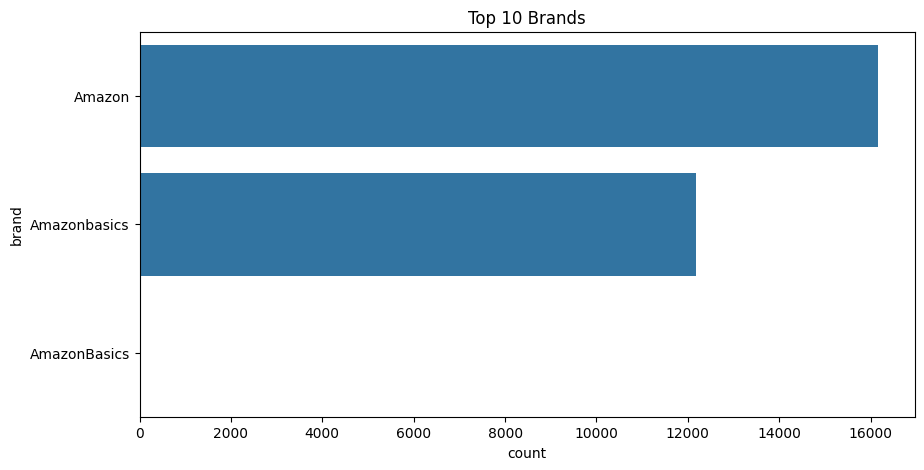

In [7]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="brand",
    order=df["brand"].value_counts().index[:10]
)

plt.title("Top 10 Brands")

plt.show()

In [8]:
df["reviews.rating"].value_counts().sort_index()

reviews.rating
1      965
2      616
3     1206
4     5648
5    19897
Name: count, dtype: int64

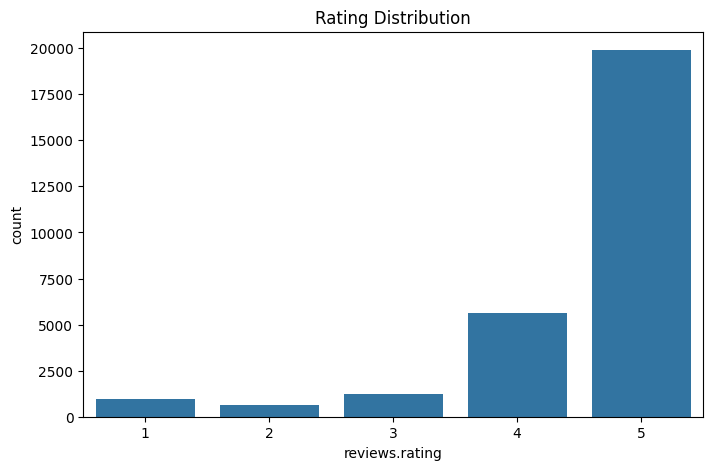

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="reviews.rating"
)

plt.title("Rating Distribution")

plt.show()

In [10]:
df["categories"].value_counts().head(10)

categories
AA,AAA,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Robot Check,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care             8343
AA,AAA,Electronics Features,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care    3728
Fire Tablets,Tablets,All Tablets,Amazon Tablets,Genuine Tablet Accessories,Computers & Tablets,Electronics,Amazon                                                                                                                                                               2443
Fire Tablets,Tablets,All Tablets,Amazon Tablets,Computers & Tablets                                                                                           

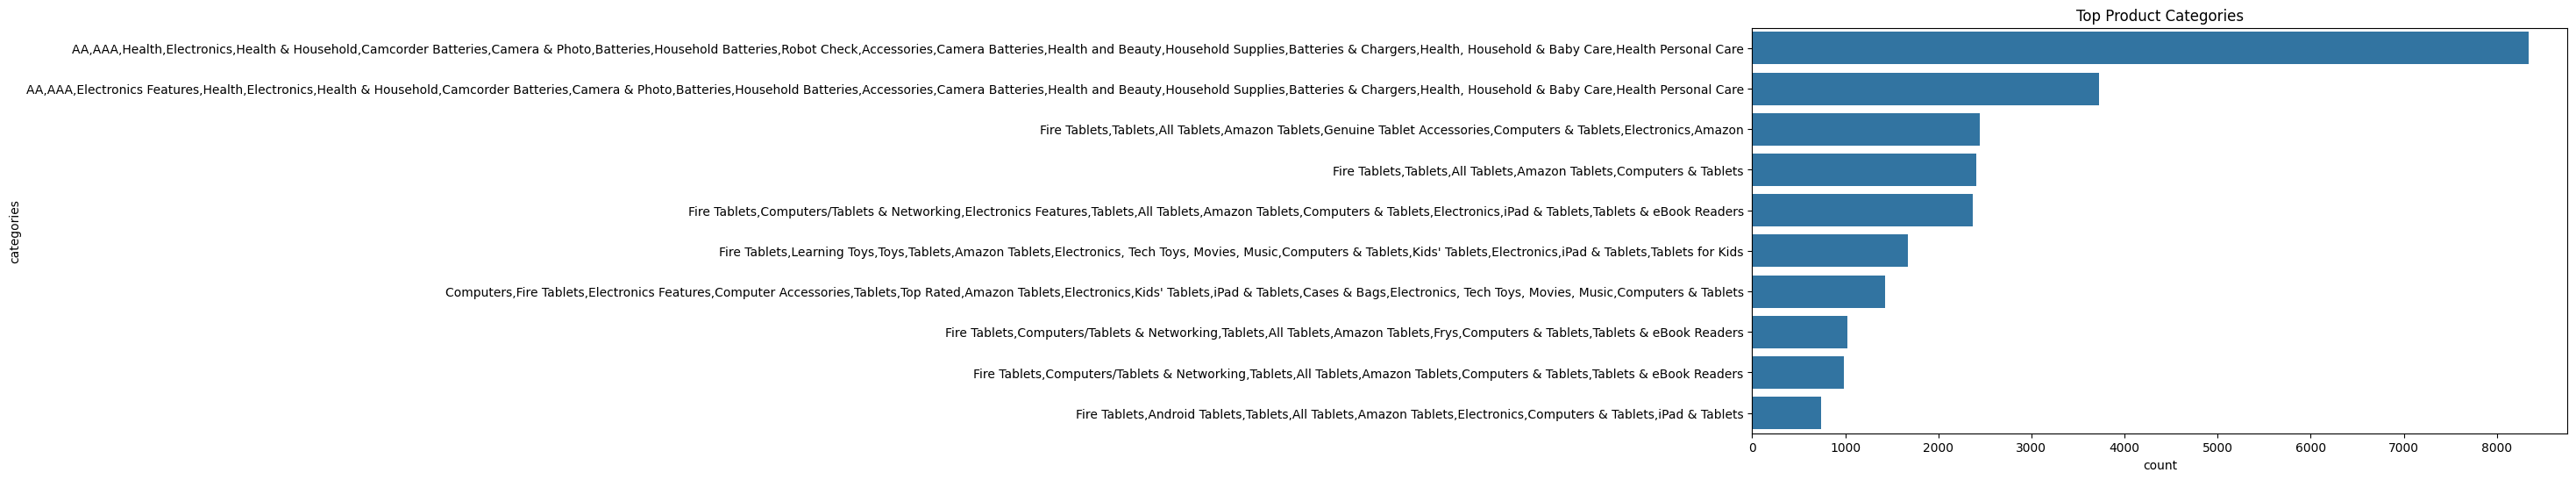

In [11]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="categories",
    order=df["categories"].value_counts().index[:10]
)

plt.title("Top Product Categories")

plt.show()

In [12]:
df["review_length"] = df["reviews.text"].astype(str).apply(len)

In [13]:
df["review_length"].describe()

count    28332.000000
mean       137.517118
std        199.877736
min          1.000000
25%         54.000000
50%         87.000000
75%        162.000000
max       8351.000000
Name: review_length, dtype: float64

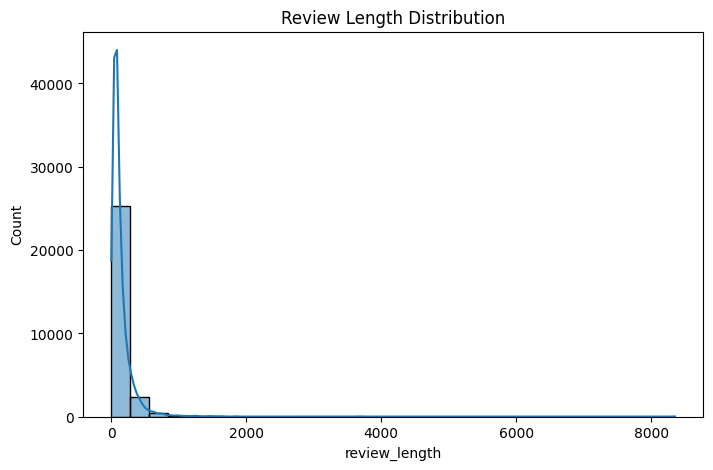

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["review_length"],
    bins=30,
    kde=True
)

plt.title("Review Length Distribution")

plt.show()

In [15]:
df["reviews.numHelpful"].describe()

count    16115.000000
mean         0.529321
std          9.345017
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        621.000000
Name: reviews.numHelpful, dtype: float64

In [16]:
df.groupby("brand")["reviews.rating"].mean().sort_values(ascending=False).head(10)

brand
Amazon          4.562620
Amazonbasics    4.449749
AmazonBasics    4.300000
Name: reviews.rating, dtype: float64

In [17]:
import re

df["clean_review"] = (
    df["reviews.text"]
      .astype(str)
      .str.lower()
      .apply(lambda x: re.sub(r"[^a-zA-Z ]","",x))
)

## Data Cleaning

In [20]:
reviews = pd.read_csv("../datasets/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv")

In [21]:
reviews.isnull().sum().sort_values(ascending=False)

reviews.didPurchase    28323
reviews.id             28291
reviews.doRecommend    12246
reviews.numHelpful     12217
reviews.username           5
id                         0
dateUpdated                0
dateAdded                  0
primaryCategories          0
categories                 0
brand                      0
asins                      0
name                       0
manufacturerNumber         0
imageURLs                  0
keys                       0
reviews.date               0
reviews.dateSeen           0
manufacturer               0
reviews.rating             0
reviews.sourceURLs         0
reviews.text               0
reviews.title              0
sourceURLs                 0
dtype: int64

In [22]:
reviews = reviews[
[
    "name",
    "brand",
    "categories",
    "reviews.rating",
    "reviews.title",
    "reviews.text",
    "reviews.date"
]
]

In [23]:
reviews.drop_duplicates(inplace=True)

In [24]:
reviews = reviews[
    reviews["reviews.text"].notnull()
]

In [25]:
reviews.drop_duplicates(inplace=True)

In [26]:
reviews = reviews[
    reviews["reviews.text"].str.strip() != ""
]

In [27]:
reviews["reviews.date"] = pd.to_datetime(
    reviews["reviews.date"],
    errors="coerce"
)

In [28]:
reviews["reviews.text"] = (
    reviews["reviews.text"]
    .str.lower()
)

In [29]:
reviews["reviews.text"] = (
    reviews["reviews.text"]
    .str.replace(r"\s+"," ",regex=True)
)

In [30]:
reviews.to_csv(
    "../datasets/clean_reviews.csv",
    index=False
)